In [40]:
import os
import numpy as np
import matplotlib.pyplot as plt
import cv2

from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score

from xgboost import XGBClassifier
import xgboost as xgb

In [41]:
import os

for dirname, _, filenames in os.walk('/kaggle/input'):
    print(dirname)

/kaggle/input
/kaggle/input/datasets
/kaggle/input/datasets/paultimothymooney
/kaggle/input/datasets/paultimothymooney/chest-xray-pneumonia
/kaggle/input/datasets/paultimothymooney/chest-xray-pneumonia/chest_xray
/kaggle/input/datasets/paultimothymooney/chest-xray-pneumonia/chest_xray/chest_xray
/kaggle/input/datasets/paultimothymooney/chest-xray-pneumonia/chest_xray/chest_xray/val
/kaggle/input/datasets/paultimothymooney/chest-xray-pneumonia/chest_xray/chest_xray/val/PNEUMONIA
/kaggle/input/datasets/paultimothymooney/chest-xray-pneumonia/chest_xray/chest_xray/val/NORMAL
/kaggle/input/datasets/paultimothymooney/chest-xray-pneumonia/chest_xray/chest_xray/test
/kaggle/input/datasets/paultimothymooney/chest-xray-pneumonia/chest_xray/chest_xray/test/PNEUMONIA
/kaggle/input/datasets/paultimothymooney/chest-xray-pneumonia/chest_xray/chest_xray/test/NORMAL
/kaggle/input/datasets/paultimothymooney/chest-xray-pneumonia/chest_xray/chest_xray/train
/kaggle/input/datasets/paultimothymooney/chest-x

In [42]:
base_dir = "/kaggle/input/datasets/paultimothymooney/chest-xray-pneumonia/chest_xray/"

train_pneumonia_dir = base_dir+'train/PNEUMONIA/'
train_normal_dir=base_dir+'train/NORMAL/'

test_pneumonia_dir = base_dir+'test/PNEUMONIA/'
test_normal_dir = base_dir+'test/NORMAL/'

val_normal_dir= base_dir+'val/NORMAL/'
val_pnrumonia_dir= base_dir+'val/PNEUMONIA/'

train_pn = [train_pneumonia_dir+"{}".format(i) for i in os.listdir(train_pneumonia_dir) ]
train_normal = [train_normal_dir+"{}".format(i) for i in os.listdir(train_normal_dir) ]

test_normal = [test_normal_dir+"{}".format(i) for i in os.listdir(test_normal_dir)]
test_pn = [test_pneumonia_dir+"{}".format(i) for i in os.listdir(test_pneumonia_dir)]

val_pn= [val_pnrumonia_dir+"{}".format(i) for i in os.listdir(val_pnrumonia_dir) ]
val_normal= [val_normal_dir+"{}".format(i) for i in os.listdir(val_normal_dir) ]

print ("Total images:",len(train_pn+train_normal+test_normal+test_pn+val_pn+val_normal))
print ("Total pneumonia images:",len(train_pn+test_pn+val_pn))
print ("Total Nomral images:",len(train_normal+test_normal+val_normal))

Total images: 5856
Total pneumonia images: 4273
Total Nomral images: 1583


In [43]:
# Dataset Splitting (train 80% , test 15% and validation 5% )
import random
# Gathering all pneumina and normal chest X-ray in two python list
pn = train_pn + test_pn + val_pn #4273
normal = train_normal + test_normal + val_normal #1583

random.seed(10)
random.shuffle(pn)
random.shuffle(normal)

# Spliting dataset in train set,test set and validation set.

train_imgs = pn[855:]+ normal[316:]  # 80% of 4273 Pneumonia and 1583 normal chest X-ray .
test_imgs = pn[:641]+ normal[:237]
val_imgs = pn[641:855] + normal[237:316]

random.seed(10)
random.shuffle(train_imgs)
random.shuffle(test_imgs)
random.shuffle(val_imgs)

print("Total Train Images %s containing %s pneumonia and %s normal images" 
      % (len(train_imgs),3418,1266))
print("Total Test Images %s containing %s pneumonia and %s normal images"
      % (len(test_imgs),641,237))
print("Total validation Images %s containing %s pneumonia and %s normal images" 
      % (len(val_imgs),214,79))

Total Train Images 4685 containing 3418 pneumonia and 1266 normal images
Total Test Images 878 containing 641 pneumonia and 237 normal images
Total validation Images 293 containing 214 pneumonia and 79 normal images


In [44]:
def preprocess_image(image_list):
    X = []
    y = []

    for image in image_list:

        try:
            img = cv2.imread(image, cv2.IMREAD_GRAYSCALE)

            img = cv2.resize(img, (128,128))

            img = img.astype(np.float32) / 255.0

            X.append(img)

        except:
            continue

        if 'NORMAL' in image:
            y.append(0)
        else:
            y.append(1)

    return np.array(X), np.array(y)

In [45]:
X_train, y_train = preprocess_image(train_imgs)
X_test, y_test = preprocess_image(test_imgs)
X_val, y_val = preprocess_image(val_imgs)

print(X_train.shape)
print(X_test.shape)
print(X_val.shape)

(4685, 128, 128)
(878, 128, 128)
(293, 128, 128)


In [46]:
#flattening 
X_train = X_train.reshape(X_train.shape[0], -1)

X_test = X_test.reshape(X_test.shape[0], -1)

X_val = X_val.reshape(X_val.shape[0], -1)

print(X_train.shape)

(4685, 16384)


In [47]:
from sklearn.decomposition import PCA

pca = PCA(n_components=500, random_state=42)

X_train_pca = pca.fit_transform(X_train)

X_val_pca = pca.transform(X_val)

X_test_pca = pca.transform(X_test)

print("Original shape :", X_train.shape)
print("PCA shape      :", X_train_pca.shape)

print("Components retained :", pca.n_components_)
print("Variance retained   :", np.sum(pca.explained_variance_ratio_))

Original shape : (4685, 16384)
PCA shape      : (4685, 500)
Components retained : 500
Variance retained   : 0.94304305


In [48]:
xgb_params = {
    'objective': 'binary:logistic',  # Changed to binary objective
    'max_depth': 6,
    'learning_rate': 0.1,
    'n_estimators': 200,
    'subsample': 0.8,
    'colsample_bytree': 0.8,
    'random_state': 42,
    'eval_metric': 'logloss',        # Changed to binary log loss
    'verbosity': 1
}

xgb_model = XGBClassifier(**xgb_params)

xgb_model.fit(
    X_train_pca,
    y_train,
    eval_set=[(X_val_pca, y_val)],
    verbose=True
)


[0]	validation_0-logloss:0.52766
[1]	validation_0-logloss:0.49554
[2]	validation_0-logloss:0.45933
[3]	validation_0-logloss:0.42256
[4]	validation_0-logloss:0.39331
[5]	validation_0-logloss:0.37374
[6]	validation_0-logloss:0.35036
[7]	validation_0-logloss:0.33784
[8]	validation_0-logloss:0.32014
[9]	validation_0-logloss:0.30254
[10]	validation_0-logloss:0.28973
[11]	validation_0-logloss:0.27771
[12]	validation_0-logloss:0.26550
[13]	validation_0-logloss:0.25509
[14]	validation_0-logloss:0.24498
[15]	validation_0-logloss:0.23833
[16]	validation_0-logloss:0.23027
[17]	validation_0-logloss:0.22651
[18]	validation_0-logloss:0.22010
[19]	validation_0-logloss:0.21669
[20]	validation_0-logloss:0.21259
[21]	validation_0-logloss:0.20980
[22]	validation_0-logloss:0.20535
[23]	validation_0-logloss:0.20198
[24]	validation_0-logloss:0.19744
[25]	validation_0-logloss:0.19582
[26]	validation_0-logloss:0.19098
[27]	validation_0-logloss:0.18740
[28]	validation_0-logloss:0.18350
[29]	validation_0-loglos

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=6, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=200, n_jobs=None,
              num_parallel_tree=None, ...)

In [49]:
y_pred = xgb_model.predict(X_test_pca)

In [50]:
from sklearn.metrics import accuracy_score

# Training accuracy
y_train_pred = xgb_model.predict(X_train_pca)
train_accuracy = accuracy_score(y_train, y_train_pred)

# Validation accuracy
y_val_pred = xgb_model.predict(X_val_pca)
val_accuracy = accuracy_score(y_val, y_val_pred)

# Test accuracy
y_test_pred = xgb_model.predict(X_test_pca)
test_accuracy = accuracy_score(y_test, y_test_pred)

print(f"Training Accuracy   : {train_accuracy*100:.2f}%")
print(f"Validation Accuracy : {val_accuracy*100:.2f}%")
print(f"Test Accuracy       : {test_accuracy*100:.2f}%")

Training Accuracy   : 100.00%
Validation Accuracy : 95.90%
Test Accuracy       : 93.96%


              precision    recall  f1-score   support

      NORMAL       0.92      0.85      0.88       237
   PNEUMONIA       0.95      0.97      0.96       641

    accuracy                           0.94       878
   macro avg       0.93      0.91      0.92       878
weighted avg       0.94      0.94      0.94       878



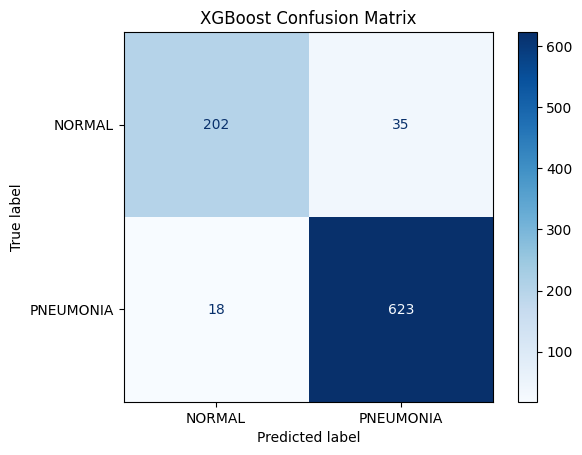

In [51]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

print(classification_report(
    y_test,
    y_test_pred,
    target_names=['NORMAL', 'PNEUMONIA']
))

y_test_pred = xgb_model.predict(X_test_pca)

cm = confusion_matrix(y_test, y_test_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['NORMAL', 'PNEUMONIA']
)

disp.plot(cmap='Blues')
plt.title("XGBoost Confusion Matrix")
plt.show()

In [52]:
# Get validation log loss history
results = xgb_model.evals_result()

val_logloss = results['validation_0']['logloss']

# Find best round and lowest log loss
best_round = np.argmin(val_logloss)
best_logloss = np.min(val_logloss)

print(f"Best Boosting Round : {best_round}")
print(f"Lowest Validation Log Loss : {best_logloss:.6f}")

Best Boosting Round : 199
Lowest Validation Log Loss : 0.108535
